# Machine learning algorithms: examples, use cases, and mock datasets

A hands-on companion to the uploaded **Cheatsheet Machine Learning Algorithms** image.
The image is a topic reference; the datasets below are generated examples, not data extracted from it.
All 17 algorithms are covered in the same order as the image.

**How to run:** select this project's `.venv` kernel and choose **Run All**. Only the existing
NumPy, pandas, matplotlib, SciPy, and scikit-learn dependencies are needed. No downloads or API keys.
Run setup first, then any numbered example; each example creates its own data with a fixed seed.

Every example explains a use case, shows mock data, and produces predictions, a visualization,
or a measurable result. CNN uses fixed filters and a trained classifier; RNN uses a fixed recurrent
reservoir and a trained readout; Transformer demonstrates attention only. These are explicitly
simplified architecture examples, not fully trained deep-learning systems.

Synthetic patterns are intentionally easy to learn. Their scores do not estimate performance on real
customers, financial transactions, images, or language. Features are inputs (`X`); targets (`y`) are
answers available during supervised training. Held-out test data is used only for evaluation.

### Map of the examples

| # | Algorithm | Learning task | Example / mock data | Output |
|---|---|---|---|---|
| 1 | Linear regression | Regression | House size, age, bedrooms | Price |
| 2 | Logistic regression | Classification | Email metadata | Spam probability |
| 3 | Decision tree | Classification | Borrower income and debt | Default class |
| 4 | Random forest | Classification | Transaction behavior | Fraud probability |
| 5 | Gradient boosting | Classification | Borrower credit features | Default probability |
| 6 | SVM | Classification | Synthetic face embeddings | Identity label |
| 7 | KNN | Classification | Reader preferences | Book genre |
| 8 | Naive Bayes | Text classification | Generated short reviews | Sentiment |
| 9 | K-means | Clustering | Customer visits and spending | Segments |
| 10 | Hierarchical clustering | Clustering | Synthetic gene expression | Dendrogram |
| 11 | PCA | Dimensionality reduction | Small grayscale images | Compressed representation |
| 12 | Neural network / MLP | Classification | Small stripe images | Image class |
| 13 | CNN | Feature demonstration + classification | Stripe images | Edge maps and class |
| 14 | RNN | Reservoir regression demonstration | Synthetic time series | Next value |
| 15 | Transformer | Attention demonstration | Token sequences | Attention weights |
| 16 | Autoencoder | Reconstruction / anomaly detection | Correlated transaction features | Reconstruction error |
| 17 | DBSCAN | Density clustering | Curved location patterns | Clusters and noise |

### Clarifications to the image

- Logistic regression models linear **log-odds**, not a linear probability; the sigmoid is `1 / (1 + exp(-z))`.
- Trees can overfit; depth limits help. Random forests aim to reduce correlation between trees;
  strict tree independence is not required, and prediction latency depends on forest size and hardware.
- Soft-margin SVMs allow classification errors; perfect separability is not required. KNN is a
  nearest-neighbor method, not specifically a few-shot learning algorithm.
- K-means favors compact, similarly sized groups. Hierarchical clustering produces a tree,
  but choosing final groups still requires a cut height or cluster count.
- PCA preserves variance, which need not be the information most relevant to a prediction target.
  Autoencoders do not require symmetric encoder and decoder architectures.
- CNNs, RNNs, and Transformers are architectures usable in multiple learning settings.
  A small Transformer can serve a small task, and pretrained models can reduce data requirements.

Further reading: [scikit-learn supervised learning](https://scikit-learn.org/stable/supervised_learning.html),
[SVM guide](https://scikit-learn.org/stable/modules/svm.html),
[Naive Bayes guide](https://scikit-learn.org/stable/modules/naive_bayes.html), and
[clustering guide](https://scikit-learn.org/stable/modules/clustering.html).

### Setup and reusable evaluation helpers

The split happens **before** fitting a scaler or vocabulary. Pipelines learn preprocessing from
training rows only. For imbalanced labels, inspect precision, recall, F1, and average precision
(the precision–recall ranking summary), rather than accuracy alone. Each classifier is compared
with a majority-class baseline; regression uses a training-mean baseline.

`datasets` keeps the generated tables/arrays in memory so you can explore or reuse them.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    average_precision_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

SEED = 42
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": False})
datasets = {}
results = {}


def evaluate_classifier(name, estimator, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=SEED
    )
    estimator.fit(X_train, y_train)
    prediction = estimator.predict(X_test)
    baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
    scores = {
        "accuracy": accuracy_score(y_test, prediction),
        "macro_F1": f1_score(y_test, prediction, average="macro", zero_division=0),
        "baseline_accuracy": accuracy_score(y_test, baseline.predict(X_test)),
    }
    if len(np.unique(y)) == 2:
        scores.update(
            precision=precision_score(y_test, prediction, zero_division=0),
            recall=recall_score(y_test, prediction, zero_division=0),
        )
        if hasattr(estimator, "predict_proba"):
            scores["average_precision"] = average_precision_score(
                y_test, estimator.predict_proba(X_test)[:, 1]
            )
    results[name] = scores
    display(pd.Series(scores, name=name).round(3))
    return estimator


def evaluate_regressor(name, estimator, X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    estimator.fit(X_train, y_train)
    prediction = estimator.predict(X_test)
    baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
    scores = {
        "MAE": mean_absolute_error(y_test, prediction),
        "R2": r2_score(y_test, prediction),
        "baseline_MAE": mean_absolute_error(y_test, baseline.predict(X_test)),
    }
    results[name] = scores
    display(pd.Series(scores, name=name).round(3))
    return estimator


def make_stripes(n=360, seed=SEED):
    rng = np.random.default_rng(seed)
    y = np.arange(n) % 2
    images = np.zeros((n, 8, 8))
    for i, label in enumerate(y):
        position = rng.integers(1, 6)
        if label == 0:
            images[i, :, position : position + 2] = 1
        else:
            images[i, position : position + 2, :] = 1
    return np.clip(images + rng.normal(0, 0.15, images.shape), 0, 1), y


print("Ready: all data is generated locally with seed", SEED)

Ready: all data is generated locally with seed 42


## 1. Linear regression — house prices

**Use case:** Estimate a continuous house price.

**Mock dataset:** 400 homes; area in square meters, bedroom count, age in years, and price in mock USD.

**How it works:** `price = intercept + w1 × area + w2 × bedrooms + w3 × age`. Least squares minimizes squared prediction errors.

**Tradeoff:** Fast and interpretable, but sensitive to outliers and missing nonlinear relationships.

In [ ]:
rng = np.random.default_rng(SEED)
homes = pd.DataFrame(
    {
        "area_m2": rng.uniform(40, 220, 400),
        "bedrooms": rng.integers(1, 6, 400),
        "age_years": rng.integers(0, 50, 400),
    }
)
homes["price_usd"] = (
    45000
    + 2300 * homes.area_m2
    + 12000 * homes.bedrooms
    - 1100 * homes.age_years
    + rng.normal(0, 18000, 400)
)
datasets["homes"] = homes
display(homes.head())
model = evaluate_regressor(
    "Linear regression", LinearRegression(), homes.drop(columns="price_usd"), homes.price_usd
)
display(pd.Series(model.coef_, index=homes.columns[:-1], name="price effect per unit"))
new_home = pd.DataFrame({"area_m2": [120], "bedrooms": [3], "age_years": [10]})
print("New home estimated price: $", round(model.predict(new_home)[0]))

,area_m2,bedrooms,age_years,price_usd
0,179.312089,1,43,453239.720238
1,118.998119,2,23,341861.644863
2,194.547626,3,49,479153.380347
3,165.526245,5,38,468221.616208
4,56.951923,4,32,189006.379276


MAE              12967.000
R2                   0.981
baseline_MAE    109509.198
Name: Linear regression, dtype: float64

area_m2       2268.435944
bedrooms     13100.583201
age_years    -1096.947594
Name: price effect per unit, dtype: float64

New home estimated price: $ 346196


: 

## 2. Logistic regression — spam detection

**Use case:** Estimate the probability that an email is spam.

**Mock dataset:** 600 emails with link count, promotional-word count, known-sender flag, and a sampled binary label.

**How it works:** A sigmoid maps a weighted feature sum to a probability; 0.5 is the default class threshold.

**Tradeoff:** Coefficients are interpretable, but nonlinear relationships need engineered features or another model.

In [3]:
rng = np.random.default_rng(SEED)
emails = pd.DataFrame(
    {
        "links": rng.poisson(2, 600),
        "promo_words": rng.poisson(3, 600),
        "known_sender": rng.integers(0, 2, 600),
    }
)
z = -3 + 0.8 * emails.links + 0.65 * emails.promo_words - 2 * emails.known_sender
emails["spam"] = rng.binomial(1, 1 / (1 + np.exp(-z)))
datasets["emails"] = emails
display(emails.head())
model = evaluate_classifier(
    "Logistic regression",
    make_pipeline(StandardScaler(), LogisticRegression()),
    emails.drop(columns="spam"),
    emails.spam,
)
new_email = pd.DataFrame({"links": [5], "promo_words": [7], "known_sender": [0]})
print("New email spam probability:", model.predict_proba(new_email)[0, 1].round(3))

,links,promo_words,known_sender,spam
0,4,3,1,1
1,3,6,0,1
2,3,4,0,1
3,2,6,0,0
4,1,1,0,0


accuracy             0.847
macro_F1             0.833
baseline_accuracy    0.607
precision            0.875
recall               0.712
average_precision    0.861
Name: Logistic regression, dtype: float64

New email spam probability: 0.996


## 3. Decision tree — loan default

**Use case:** Explain a small set of rules for a mock default prediction.

**Mock dataset:** 500 borrowers with annual income in mock USD, debt-to-income ratio, late payments, and default label.

**How it works:** Recursively choose feature thresholds that reduce class impurity.

**Tradeoff:** Easy to visualize at shallow depth; deep trees can memorize noise. No scaling is needed.

,income_usd,debt_ratio,late_payments,default
0,97395.604856,0.602529,0,1
1,63887.843975,0.714802,1,1
2,105859.791991,0.740793,0,1
3,89736.802906,0.427725,1,0
4,29417.734789,0.440206,1,0


accuracy             0.912
macro_F1             0.912
baseline_accuracy    0.536
precision            0.898
recall               0.914
average_precision    0.862
Name: Decision tree, dtype: float64

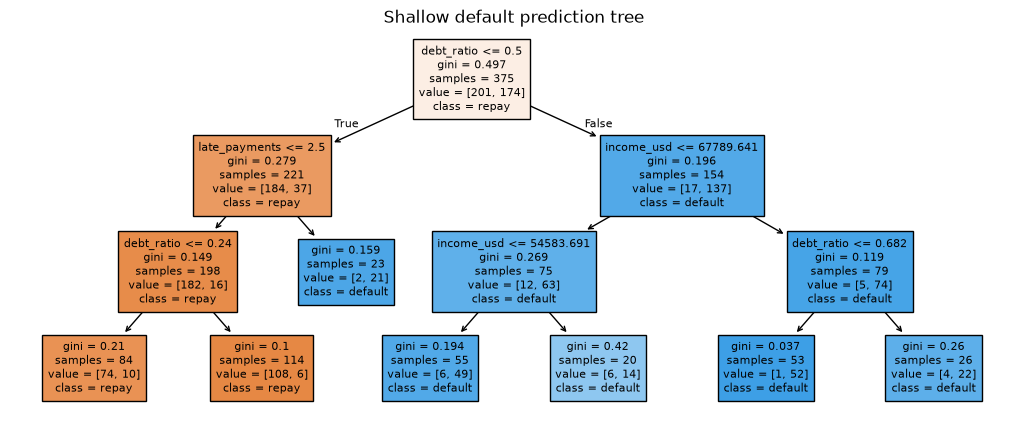

In [4]:
rng = np.random.default_rng(SEED)
loans = pd.DataFrame(
    {
        "income_usd": rng.uniform(20000, 120000, 500),
        "debt_ratio": rng.uniform(0.05, 0.8, 500),
        "late_payments": rng.poisson(1.2, 500),
    }
)
loans["default"] = ((loans.debt_ratio > 0.5) | (loans.late_payments >= 3)).astype(int)
flip = rng.random(500) < 0.08
loans.loc[flip, "default"] = 1 - loans.loc[flip, "default"]
datasets["loans"] = loans
display(loans.head())
model = evaluate_classifier(
    "Decision tree",
    DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=SEED),
    loans.drop(columns="default"),
    loans.default,
)
plt.figure(figsize=(13, 5))
plot_tree(
    model,
    feature_names=list(loans.columns[:-1]),
    class_names=["repay", "default"],
    filled=True,
    fontsize=8,
)
plt.title("Shallow default prediction tree")
plt.show()

## 4. Random forest — transaction fraud

**Use case:** Rank unusual transactions for review.

**Mock dataset:** 1,000 transactions with amount, distance from usual location in km, night flag, and rare fraud labels.

**How it works:** Fit trees on bootstrap samples with random feature subsets, then average their probabilities.

**Tradeoff:** Flexible and robust, but less transparent than one tree. Accuracy can hide missed rare events.

In [5]:
rng = np.random.default_rng(SEED)
transactions = pd.DataFrame(
    {
        "amount_usd": rng.lognormal(3.5, 1.1, 1000),
        "distance_km": rng.exponential(40, 1000),
        "night": rng.integers(0, 2, 1000),
    }
)
risky = ((transactions.amount_usd > 100) & (transactions.distance_km > 70)) | (
    (transactions.night == 1) & (transactions.distance_km > 120)
)
transactions["fraud"] = rng.binomial(1, np.where(risky, 0.8, 0.015))
datasets["transactions"] = transactions
display(transactions.head())
print("Fraud prevalence:", transactions.fraud.mean().round(3))
model = evaluate_classifier(
    "Random forest",
    RandomForestClassifier(
        n_estimators=100, min_samples_leaf=3, class_weight="balanced", random_state=SEED, n_jobs=1
    ),
    transactions.drop(columns="fraud"),
    transactions.fraud,
)
new_transaction = pd.DataFrame({"amount_usd": [220], "distance_km": [180], "night": [1]})
print("Fraud probability:", model.predict_proba(new_transaction)[0, 1].round(3))

,amount_usd,distance_km,night,fraud
0,46.302168,15.407778,1,1
1,10.548857,9.110759,1,0
2,75.603026,12.688197,1,0
3,93.188208,5.113874,1,0
4,3.872349,43.766337,0,0


Fraud prevalence: 0.057


accuracy             0.928
macro_F1             0.731
baseline_accuracy    0.944
precision            0.409
recall               0.643
average_precision    0.663
Name: Random forest, dtype: float64

Fraud probability: 0.969


## 5. Gradient boosting — credit risk

**Use case:** Estimate mock default risk from interacting borrower features.

**Mock dataset:** 700 borrowers with debt ratio, utilization, employment years, and a noisy binary default outcome.

**How it works:** Add shallow trees sequentially to reduce the current prediction loss.

**Tradeoff:** Strong for tabular data but sensitive to learning rate and tree complexity; tune on validation data.

In [6]:
rng = np.random.default_rng(SEED)
credit = pd.DataFrame(
    {
        "debt_ratio": rng.uniform(0, 1, 700),
        "utilization": rng.uniform(0, 1, 700),
        "employment_years": rng.integers(0, 25, 700),
    }
)
z = (
    -3
    + 3 * credit.debt_ratio
    + 2 * credit.utilization
    + 2 * ((credit.debt_ratio > 0.65) & (credit.utilization > 0.7))
    - 0.08 * credit.employment_years
)
credit["default"] = rng.binomial(1, 1 / (1 + np.exp(-z)))
datasets["credit"] = credit
display(credit.head())
model = evaluate_classifier(
    "Gradient boosting",
    GradientBoostingClassifier(n_estimators=80, learning_rate=0.05, max_depth=2, random_state=SEED),
    credit.drop(columns="default"),
    credit.default,
)
new_borrower = pd.DataFrame({"debt_ratio": [0.8], "utilization": [0.9], "employment_years": [1]})
print("Default probability:", model.predict_proba(new_borrower)[0, 1].round(3))

,debt_ratio,utilization,employment_years,default
0,0.773956,0.241372,19,0
1,0.438878,0.322492,11,0
2,0.858598,0.155442,24,1
3,0.697368,0.874314,1,1
4,0.094177,0.283247,4,0


accuracy             0.811
macro_F1             0.725
baseline_accuracy    0.720
precision            0.786
recall               0.449
average_precision    0.735
Name: Gradient boosting, dtype: float64

Default probability: 0.846


## 6. SVM — synthetic identity embeddings

**Use case:** Classify a vector representation of an image into one of three mock identities.

**Mock dataset:** 240 synthetic 12-dimensional embedding vectors; these are not actual faces or a face recognition system.

**How it works:** Find separating margins; an RBF kernel allows nonlinear boundaries.

**Tradeoff:** Scaling matters and kernel training can be expensive for large datasets. Real identity systems need unseen-person evaluation.

In [7]:
rng = np.random.default_rng(SEED)
identity = np.repeat(np.arange(3), 80)
centers = rng.normal(0, 1.5, (3, 12))
embeddings = centers[identity] + rng.normal(0, 1, (240, 12))
faces = pd.DataFrame(embeddings, columns=[f"embedding_{i}" for i in range(12)])
faces["identity"] = identity
datasets["face_embeddings"] = faces
display(faces.head())
model = evaluate_classifier(
    "SVM",
    make_pipeline(StandardScaler(), SVC(C=1, kernel="rbf")),
    faces.drop(columns="identity"),
    identity,
)
new_embedding = pd.DataFrame([centers[1] + rng.normal(0, 1, 12)], columns=faces.columns[:-1])
print("New synthetic identity prediction:", model.predict(new_embedding)[0])

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,embedding_11,identity
0,0.343128,-2.400133,0.301196,2.061440,-2.183299,-1.410115,-0.473749,-0.242203,0.091484,-1.060877,2.190526,1.390283,0
1,1.135989,-1.492397,1.414796,2.042135,-4.383709,-2.272940,-0.278612,-1.113242,-0.300344,0.215375,0.453266,2.134966,0
2,-1.225794,-1.894861,1.288430,1.997069,-2.215326,-1.159922,-0.156964,-0.936716,0.832774,-1.470870,0.043411,0.033401,0
3,-0.462377,-1.062815,1.268103,2.101332,-3.353805,-1.794730,0.817351,-0.783710,0.431574,-1.941492,0.956043,0.784950,0
4,-0.738764,-1.073004,0.656274,1.423341,-2.445806,-1.506738,0.857146,-0.572849,-0.448500,-1.359284,-0.368237,-0.280425,0


accuracy             0.983
macro_F1             0.983
baseline_accuracy    0.333
Name: SVM, dtype: float64

New synthetic identity prediction: 1


## 7. KNN — book genre recommendation

**Use case:** Suggest a genre based on similar reader preferences.

**Mock dataset:** 300 readers with action, romance, and science preference scores from 0 to 10; three preferred-genre labels.

**How it works:** Vote among the five closest standardized feature vectors.

**Tradeoff:** Simple similarity baseline; many irrelevant features hurt distance quality. This is genre classification, not collaborative filtering.

In [8]:
rng = np.random.default_rng(SEED)
readers = pd.DataFrame(rng.uniform(0, 10, (300, 3)), columns=["action", "romance", "science"])
genres = np.array(["adventure", "romance", "science fiction"])
readers["genre"] = genres[np.argmax(readers.to_numpy() + rng.normal(0, 0.8, (300, 3)), axis=1)]
datasets["readers"] = readers
display(readers.head())
model = evaluate_classifier(
    "KNN",
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    readers.drop(columns="genre"),
    readers.genre,
)
new_reader = pd.DataFrame({"action": [3], "romance": [2], "science": [9]})
print("Suggested genre:", model.predict(new_reader)[0])

,action,romance,science,genre
0,7.739560,4.388784,8.585979,science fiction
1,6.973680,0.941773,9.756224,science fiction
2,7.611397,7.860643,1.281136,romance
3,4.503859,3.707980,9.267650,science fiction
4,6.438651,8.227616,4.434142,romance


accuracy             0.840
macro_F1             0.837
baseline_accuracy    0.360
Name: KNN, dtype: float64

Suggested genre: science fiction


## 8. Naive Bayes — sentiment analysis

**Use case:** Classify short mock product reviews as positive or negative.

**Mock dataset:** 240 unique template-generated reviews made from a small sentiment vocabulary and product nouns.

**How it works:** Combine class priors with word-count likelihoods under conditional feature independence.

**Tradeoff:** Fast with text but word order and negation are difficult. Template-generated test scores are optimistic.

In [9]:
rng = np.random.default_rng(SEED)
positive = ["great", "excellent", "lovely", "wonderful", "reliable", "amazing"]
negative = ["awful", "terrible", "poor", "broken", "disappointing", "unreliable"]
products = ["camera", "keyboard", "speaker", "screen", "phone", "headphones", "tablet", "watch"]
rows = []
for label, words in [(0, negative), (1, positive)]:
    candidates = [
        f"the {product} is {a} and {b}"
        for product in products
        for a in words
        for b in words
        if a != b
    ]
    rows.extend((candidates[i], label) for i in rng.choice(len(candidates), 120, replace=False))
reviews = pd.DataFrame(rows, columns=["text", "positive"])
datasets["reviews"] = reviews
display(reviews.sample(5, random_state=SEED))
model = evaluate_classifier(
    "Naive Bayes", make_pipeline(CountVectorizer(), MultinomialNB()), reviews.text, reviews.positive
)
new_reviews = ["excellent reliable camera", "terrible broken phone", "not great"]
display(
    pd.DataFrame(
        {"review": new_reviews, "positive_probability": model.predict_proba(new_reviews)[:, 1]}
    )
)
print("The model has no learned rule for 'not': inspect the last prediction.")

,text,positive
24,the tablet is terrible and disappointing,0
6,the screen is disappointing and unreliable,0
93,the watch is poor and broken,0
109,the speaker is terrible and broken,0
104,the keyboard is awful and unreliable,0


accuracy             1.0
macro_F1             1.0
baseline_accuracy    0.5
precision            1.0
recall               1.0
average_precision    1.0
Name: Naive Bayes, dtype: float64

,review,positive_probability
0,excellent reliable camera,0.999234
1,terrible broken phone,0.001017
2,not great,0.970588


The model has no learned rule for 'not': inspect the last prediction.


## 9. K-means — customer segmentation

**Use case:** Group customers by visit frequency and spending.

**Mock dataset:** 300 customers around three synthetic centers; visits per month and monthly spending in mock USD.

**How it works:** Alternate between nearest-centroid assignment and centroid updates to reduce squared distances.

**Tradeoff:** Choose K in advance; scaling changes the distance geometry. Cluster numbers have no intrinsic business meaning.

,visits_month,spend_usd,cluster
0,2.304717,33.600556,2
1,2.750451,102.919765,2
2,0.048965,24.423717,2
3,2.127840,58.931509,2
4,1.983199,40.143463,2


,visits_month,spend_usd
cluster,,
0,9.1,219.3
1,16.9,649.1
2,2.0,68.4


Silhouette (higher indicates more separated compact groups): 0.824


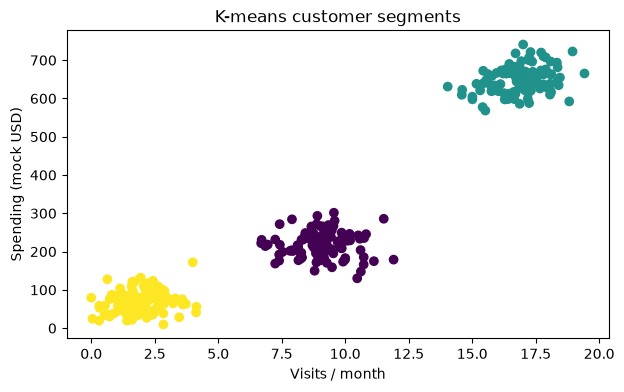

In [10]:
rng = np.random.default_rng(SEED)
centers = np.array([[2, 70], [9, 220], [17, 650]])
values = np.vstack([rng.normal(c, [1.0, 35], size=(100, 2)) for c in centers])
customers = pd.DataFrame(np.maximum(values, 0), columns=["visits_month", "spend_usd"])
scaled = StandardScaler().fit_transform(customers)
clusters = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit_predict(scaled)
datasets["customers"] = customers.assign(cluster=clusters)
display(datasets["customers"].head())
display(datasets["customers"].groupby("cluster").mean().round(1))
print(
    "Silhouette (higher indicates more separated compact groups):",
    round(silhouette_score(scaled, clusters), 3),
)
plt.scatter(customers.visits_month, customers.spend_usd, c=clusters, cmap="viridis")
plt.xlabel("Visits / month")
plt.ylabel("Spending (mock USD)")
plt.title("K-means customer segments")
plt.show()

## 10. Hierarchical clustering — gene expression

**Use case:** Explore similarity between biological samples using a tree of merges.

**Mock dataset:** 24 synthetic samples × 6 genes in arbitrary expression units; no real biological interpretation.

**How it works:** Ward linkage repeatedly merges groups with the smallest increase in within-group variance.

**Tradeoff:** The dendrogram shows multiple possible groupings, but choosing final clusters still requires a cut. Pairwise work grows quickly.

,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,cluster
0,1.106651,0.636006,4.262658,4.329198,0.317138,0.544237,1
1,1.044744,0.889315,3.994120,3.701435,1.307789,1.272227,1
2,1.023111,1.394534,4.163628,3.699248,1.129063,0.664391,1
3,1.307458,0.982526,3.935298,3.761675,1.427889,0.945915,1
4,0.850085,0.876753,4.186308,4.127905,1.144456,1.150787,1


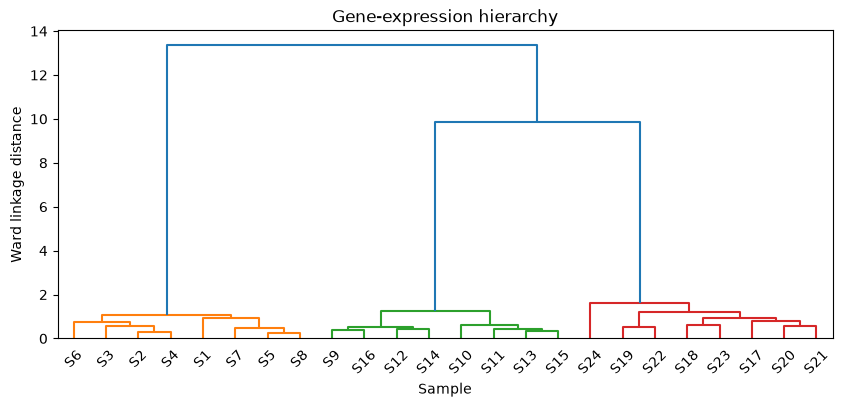

In [11]:
rng = np.random.default_rng(SEED)
profiles = np.array([[1, 1, 4, 4, 1, 1], [4, 4, 1, 1, 2, 2], [2, 2, 2, 2, 5, 5]])
genes = pd.DataFrame(
    np.vstack([rng.normal(c, 0.35, (8, 6)) for c in profiles]),
    columns=[f"gene_{i + 1}" for i in range(6)],
)
scaled = StandardScaler().fit_transform(genes)
clusters = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(scaled)
datasets["gene_expression"] = genes.assign(cluster=clusters)
display(datasets["gene_expression"].head())
plt.figure(figsize=(10, 4))
dendrogram(linkage(scaled, method="ward"), labels=[f"S{i + 1}" for i in range(24)])
plt.xlabel("Sample")
plt.ylabel("Ward linkage distance")
plt.title("Gene-expression hierarchy")
plt.show()

## 11. PCA — image compression

**Use case:** Represent an image with fewer numbers and reconstruct it approximately.

**Mock dataset:** 240 generated 8 × 8 grayscale stripe images; each flattened image has 64 pixel features.

**How it works:** Project centered images onto orthogonal directions capturing the most training-set variance.

**Tradeoff:** Lossy compression may erase useful details. The component basis also costs storage, so this is a representation demo, not a file-size benchmark.

Held-out representation shape: (60, 64) -> (60, 10)
Training variance retained: 0.958
Held-out reconstruction MSE: 0.007


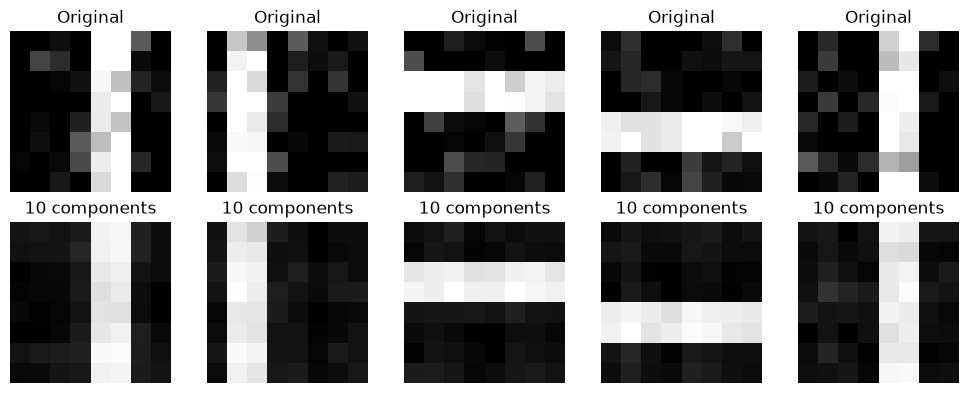

In [12]:
images, labels = make_stripes(240)
datasets["pca_images"] = {"images": images, "orientation": labels}
train, test = train_test_split(images.reshape(240, -1), test_size=0.25, random_state=SEED)
pca = PCA(n_components=10, random_state=SEED).fit(train)
compressed = pca.transform(test)
reconstructed = pca.inverse_transform(compressed)
print("Held-out representation shape:", test.shape, "->", compressed.shape)
print("Training variance retained:", round(pca.explained_variance_ratio_.sum(), 3))
print("Held-out reconstruction MSE:", round(mean_squared_error(test, reconstructed), 4))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(test[i].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(reconstructed[i].reshape(8, 8), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("Original")
    axes[1, i].set_title("10 components")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 12. Neural network (MLP) — image classification

**Use case:** Learn to distinguish vertical and horizontal stripe images.

**Mock dataset:** 360 generated 8 × 8 images with noise; 0 = vertical and 1 = horizontal.

**How it works:** A fully connected hidden layer combines weighted inputs and nonlinear activations; training adjusts weights to reduce classification loss.

**Tradeoff:** Can learn nonlinear patterns but ignores explicit spatial structure. This small problem does not demonstrate real-world vision quality.

In [13]:
images, labels = make_stripes()
datasets["mlp_images"] = {"images": images, "orientation": labels}
print("Mock dataset:", images.shape, "; first six labels:", labels[:6])
model = evaluate_classifier(
    "MLP",
    make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(24,), solver="lbfgs", max_iter=400, random_state=SEED),
    ),
    images.reshape(len(images), -1),
    labels,
)
new_images, _ = make_stripes(4, seed=123)
print("New image predictions (0 vertical, 1 horizontal):", model.predict(new_images.reshape(4, -1)))

Mock dataset: (360, 8, 8) ; first six labels: [0 1 0 1 0 1]


accuracy             1.0
macro_F1             1.0
baseline_accuracy    0.5
precision            1.0
recall               1.0
average_precision    1.0
Name: MLP, dtype: float64

New image predictions (0 vertical, 1 horizontal): [0 1 0 1]


## 13. CNN — convolution and pooling demonstration

**Use case:** Detect local edges, a building block for image recognition and vehicle vision.

**Mock dataset:** 360 noisy 8 × 8 stripe images, with the same two orientation classes.

**How it works:** Slide two fixed edge filters over each image, apply ReLU, average each feature map, then train a logistic classifier.

**Tradeoff:** This is a convolutional feature demonstration with a trained head. A full CNN learns its filters by backpropagation; this example does not.

,vertical_edge,horizontal_edge
0,0.404291,0.041003
1,0.125945,0.935124
2,0.911459,0.071799
3,0.028262,0.956872
4,0.907720,0.083825


accuracy             1.0
macro_F1             1.0
baseline_accuracy    0.5
precision            1.0
recall               1.0
average_precision    1.0
Name: CNN fixed features, dtype: float64

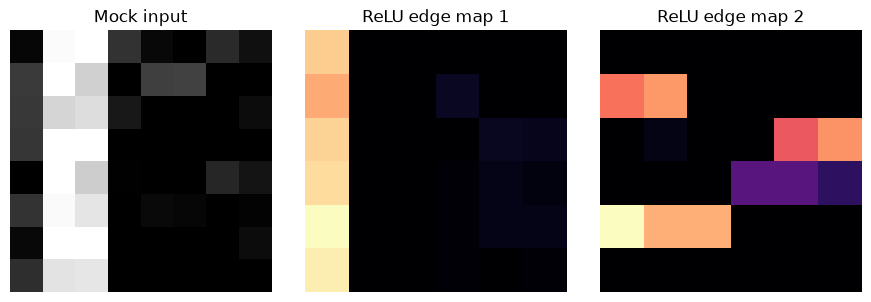

In [14]:
images, labels = make_stripes()
datasets["cnn_images"] = {"images": images, "orientation": labels}
filters = np.array(
    [[[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], [[-1, -1, -1], [0, 0, 0], [1, 1, 1]]], dtype=float
)
# Cross-correlation, commonly called convolution in CNN implementations.
windows = np.lib.stride_tricks.sliding_window_view(images, (3, 3), axis=(1, 2))
feature_maps = np.maximum(0, np.einsum("nhwij,kij->nhwk", windows, filters))
pooled = feature_maps.mean(axis=(1, 2))
display(pd.DataFrame(pooled[:5], columns=["vertical_edge", "horizontal_edge"]))
model = evaluate_classifier(
    "CNN fixed features", make_pipeline(StandardScaler(), LogisticRegression()), pooled, labels
)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(images[0], cmap="gray")
axes[0].set_title("Mock input")
for i in range(2):
    axes[i + 1].imshow(feature_maps[0, :, :, i], cmap="magma")
    axes[i + 1].set_title(f"ReLU edge map {i + 1}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 14. RNN — next-value time-series prediction

**Use case:** Predict the next observation in a synthetic sequence, analogous to a demand forecasting exercise.

**Mock dataset:** 320 time steps of a noisy periodic signal; each input contains the preceding 12 observations.

**How it works:** `h_t = tanh(x_t W_x + h_(t-1) W_h + b)` reuses the same recurrent weights over time. Here weights stay fixed and Ridge learns the output.

**Tradeoff:** This reservoir-style RNN is not trained by backpropagation through time. Synthetic periodic forecasting does not demonstrate stock predictability.

Use a chronological split. Training and validation targets precede test targets. At each test step,
the actual preceding observations are available: this is **rolling one-step prediction**, not a
multi-step forecast generated without new measurements. Compare with persistence (the last value).

,step,value
0,0,0.324377
1,1,0.318358
2,2,0.543709
3,3,0.621947
4,4,0.435964


MAE             0.102
baseline_MAE    0.126
dtype: float64

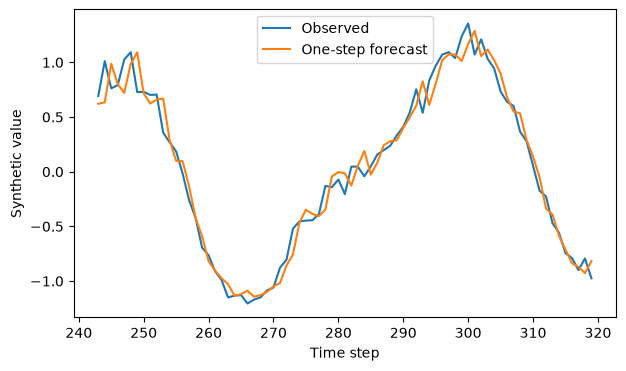

In [15]:
rng = np.random.default_rng(SEED)
t = np.arange(320)
series = np.sin(t / 9) + 0.3 * np.cos(t / 4) + rng.normal(0, 0.08, len(t))
window = 12
windows = np.lib.stride_tricks.sliding_window_view(series, window + 1)
X, y = windows[:, :-1], windows[:, -1]
cut = int(len(X) * 0.75)
mean, std = series[: cut + window].mean(), series[: cut + window].std()
# Normalize using only observations preceding the first test target.
X_scaled = (X - mean) / std
Wx = rng.normal(0, 0.4, (1, 24))
Wh = rng.normal(0, 0.15, (24, 24))
Wh *= 0.8 / np.max(np.abs(np.linalg.eigvals(Wh)))
bias = rng.normal(0, 0.1, 24)


def recurrent_features(batch):
    hidden = np.zeros((len(batch), 24))
    for step in range(batch.shape[1]):
        hidden = np.tanh(batch[:, step : step + 1] @ Wx + hidden @ Wh + bias)
    return hidden


features = recurrent_features(X_scaled)
readout = Ridge(alpha=0.1).fit(features[:cut], y[:cut])
prediction = readout.predict(features[cut:])
results["RNN fixed reservoir"] = {
    "MAE": mean_absolute_error(y[cut:], prediction),
    "baseline_MAE": mean_absolute_error(y[cut:], X[cut:, -1]),
}
datasets["time_series"] = pd.DataFrame({"step": t, "value": series})
display(datasets["time_series"].head())
display(pd.Series(results["RNN fixed reservoir"]).round(3))
plt.plot(t[window + cut :], y[cut:], label="Observed")
plt.plot(t[window + cut :], prediction, label="One-step forecast")
plt.xlabel("Time step")
plt.ylabel("Synthetic value")
plt.legend()
plt.show()

## 15. Transformer — inspect self-attention

**Use case:** Understand how a token can combine information from other tokens, a building block for language models.

**Mock dataset:** Three short token sequences and hand-designed 4-dimensional toy embeddings; no pretrained vocabulary or language model.

**How it works:** `attention(Q,K,V) = softmax(Q Kᵀ / sqrt(d)) V`. Position encodings identify order. A causal mask hides future tokens.

**Tradeoff:** This single-head forward pass has no training, feed-forward block, residual layers, or token generation. It is not BERT or GPT.

,tokens
0,"[the, cat, likes, fish]"
1,"[the, dog, likes, food]"
2,"[the, cat, likes, food]"


,the,cat,likes,fish
the,1.000,0.000,0.000,0.000
cat,0.255,0.745,0.000,0.000
likes,0.329,0.403,0.267,0.000
fish,0.130,0.216,0.143,0.511


Context vectors shape: (4, 4)


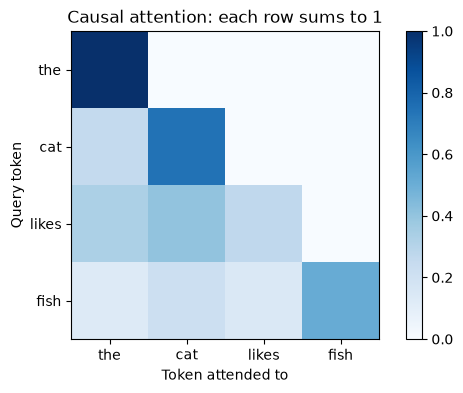

In [16]:
token_sequences = [
    ["the", "cat", "likes", "fish"],
    ["the", "dog", "likes", "food"],
    ["the", "cat", "likes", "food"],
]
embeddings = {
    "the": [0, 0, 0, 1],
    "cat": [1, 0, 0, 0],
    "dog": [0.8, 0.2, 0, 0],
    "likes": [0, 1, 0, 0],
    "fish": [0.7, 0, 1, 0],
    "food": [0.5, 0, 1, 0],
}
datasets["token_sequences"] = pd.DataFrame({"tokens": token_sequences})
display(datasets["token_sequences"])
tokens = token_sequences[0]
x = np.array([embeddings[token] for token in tokens], dtype=float)
positions = np.arange(len(tokens))[:, None]
rates = 1 / (10000 ** (np.arange(0, 4, 2) / 4))
encoding = np.zeros_like(x)
encoding[:, 0::2] = np.sin(positions * rates)
encoding[:, 1::2] = np.cos(positions * rates)
x = x + encoding
# Identity projections keep the mechanics visible; real models learn Q/K/V projections.
Q, K, V = x, x, x
scores = Q @ K.T / np.sqrt(x.shape[1])
scores[np.triu_indices(len(tokens), k=1)] = -np.inf
weights = np.exp(scores - scores.max(axis=1, keepdims=True))
weights /= weights.sum(axis=1, keepdims=True)
context = weights @ V
assert np.allclose(weights.sum(axis=1), 1)
assert np.allclose(weights[np.triu_indices(len(tokens), k=1)], 0)
display(pd.DataFrame(weights, index=tokens, columns=tokens).round(3))
print("Context vectors shape:", context.shape)
plt.imshow(weights, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Token attended to")
plt.ylabel("Query token")
plt.title("Causal attention: each row sums to 1")
plt.colorbar()
plt.show()

## 16. Autoencoder — anomaly detection

**Use case:** Flag transactions whose feature relationships differ from normal training examples.

**Mock dataset:** 500 normal training rows, 150 normal validation rows, and a held-out test set of 150 normal + 40 anomalous rows; six standardized-behavior features.

**How it works:** Train a 6 → 3 → 6 neural network to reconstruct its input; unusually large reconstruction error becomes an anomaly score.

**Tradeoff:** Reconstruction error is not proof of fraud. Set thresholds on validation data; anomalies resembling the training distribution may be missed.

,behavior_0,behavior_1,behavior_2,behavior_3,behavior_4,behavior_5
0,0.124168,-0.557560,-0.052990,-0.981164,0.866639,0.768867
1,0.005659,-0.164881,0.392470,1.198021,-1.635001,-1.227841
2,-0.178856,-0.109410,0.118423,1.167688,-1.563056,-1.142348
3,0.356307,-0.881564,0.620044,0.907641,-1.800026,-1.182843
4,-0.064490,0.362971,-0.062835,0.461180,-0.314518,-0.210986


Validation-derived threshold: 0.0066


precision            0.755
recall               1.000
average_precision    1.000
dtype: float64

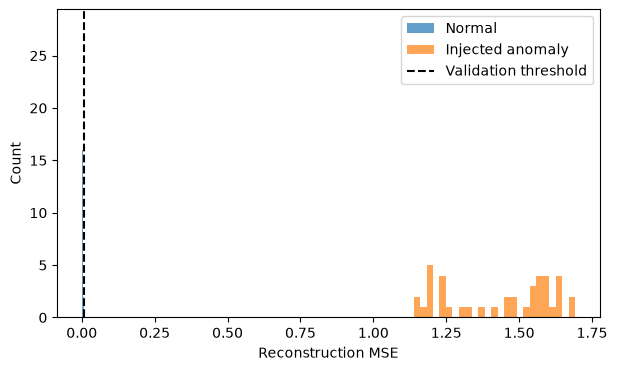

In [17]:
rng = np.random.default_rng(SEED)
loading = rng.normal(size=(2, 6))


def normal_transactions(n):
    return rng.normal(size=(n, 2)) @ loading + rng.normal(0, 0.08, (n, 6))


train = normal_transactions(500)
validation = normal_transactions(150)
normal_test = normal_transactions(150)
anomalies = normal_transactions(40)
# Break the learned correlations in two features.
anomalies[:, [1, 4]] += rng.choice([-1, 1], (40, 2)) * 4
X_test = np.vstack([normal_test, anomalies])
y_test = np.r_[np.zeros(150, dtype=int), np.ones(40, dtype=int)]
columns = [f"behavior_{i}" for i in range(6)]
datasets["autoencoder_train"] = pd.DataFrame(train, columns=columns)
datasets["autoencoder_validation"] = pd.DataFrame(validation, columns=columns)
datasets["autoencoder_test"] = pd.DataFrame(X_test, columns=columns).assign(anomaly=y_test)
display(datasets["autoencoder_train"].head())
scaler = StandardScaler().fit(train)
train_s = scaler.transform(train)
# The target is the input itself. Only normal observations train the model.
autoencoder = MLPRegressor(
    hidden_layer_sizes=(3,), activation="tanh", solver="lbfgs", max_iter=1500, random_state=SEED
).fit(train_s, train_s)


def reconstruction_error(rows):
    scaled = scaler.transform(rows)
    return np.mean((scaled - autoencoder.predict(scaled)) ** 2, axis=1)


threshold = np.quantile(reconstruction_error(validation), 0.95)
errors = reconstruction_error(X_test)
prediction = (errors > threshold).astype(int)
print("Validation-derived threshold:", round(threshold, 4))
display(
    pd.Series(
        {
            "precision": precision_score(y_test, prediction, zero_division=0),
            "recall": recall_score(y_test, prediction, zero_division=0),
            "average_precision": average_precision_score(y_test, errors),
        }
    ).round(3)
)
plt.hist(errors[y_test == 0], bins=25, alpha=0.7, label="Normal")
plt.hist(errors[y_test == 1], bins=25, alpha=0.7, label="Injected anomaly")
plt.axvline(threshold, color="black", linestyle="--", label="Validation threshold")
plt.xlabel("Reconstruction MSE")
plt.ylabel("Count")
plt.legend()
plt.show()

## 17. DBSCAN — spatial clusters and noise

**Use case:** Find dense curved groups of mock locations without choosing the number of groups.

**Mock dataset:** 300 points on two curved patterns plus 25 uniformly scattered points; x/y are local coordinates in mock km, not latitude/longitude.

**How it works:** Connect dense neighborhoods controlled by radius `eps` and minimum samples; label unsupported points as noise (`-1`).

**Tradeoff:** Sensitive to units, neighborhood radius, and varying density. Real latitude/longitude requires an appropriate geographic distance.

,x_km,y_km,cluster
0,0.616472,-0.374791,0
1,1.890597,-0.136772,0
2,-0.062399,0.456290,0
3,0.938714,0.232597,1
4,1.180150,-0.490161,0


Detected clusters: 2
Points labeled noise: 15
Adjusted Rand index on the 300 curved-pattern points: 1.0


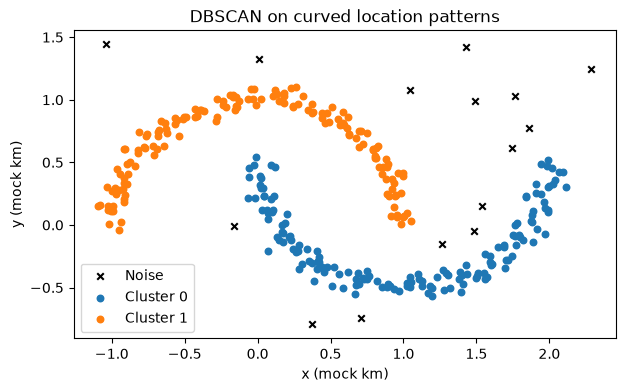

In [18]:
from sklearn.datasets import make_moons

rng = np.random.default_rng(SEED)
points, true_group = make_moons(n_samples=300, noise=0.045, random_state=SEED)
noise = rng.uniform([-1.4, -0.9], [2.4, 1.5], (25, 2))
locations = pd.DataFrame(np.vstack([points, noise]), columns=["x_km", "y_km"])
clusters = DBSCAN(eps=0.17, min_samples=6).fit_predict(locations)
datasets["locations"] = locations.assign(cluster=clusters)
display(datasets["locations"].head())
print("Detected clusters:", len(set(clusters) - {-1}))
print("Points labeled noise:", np.sum(clusters == -1))
# Synthetic source labels are used only for evaluation, never passed to DBSCAN.
print(
    "Adjusted Rand index on the 300 curved-pattern points:",
    round(adjusted_rand_score(true_group, clusters[:300]), 3),
)
for label in sorted(set(clusters)):
    mask = clusters == label
    plt.scatter(
        locations.loc[mask, "x_km"],
        locations.loc[mask, "y_km"],
        label="Noise" if label == -1 else f"Cluster {label}",
        s=22,
        **({"c": "black", "marker": "x"} if label == -1 else {}),
    )
plt.xlabel("x (mock km)")
plt.ylabel("y (mock km)")
plt.title("DBSCAN on curved location patterns")
plt.legend()
plt.show()

## Explore the mock datasets and results

These scores belong to **different tasks and datasets**. They are not an algorithm leaderboard.
Missing metric values mean the metric was not computed for that task. Re-running an example
replaces its registered data and scores. Re-running setup clears the registry.

In [19]:
inventory = []
for name, data in datasets.items():
    shape = (
        data.shape if hasattr(data, "shape") else {key: value.shape for key, value in data.items()}
    )
    inventory.append({"dataset": name, "shape": str(shape)})
display(pd.DataFrame(inventory))
display(pd.DataFrame(results).T.round(3))
# Example: inspect a generated dataset directly.
display(datasets["homes"].describe().round(2))

,dataset,shape
0,homes,"(400, 4)"
1,emails,"(600, 4)"
2,loans,"(500, 4)"
3,transactions,"(1000, 4)"
4,credit,"(700, 4)"
5,face_embeddings,"(240, 13)"
6,readers,"(300, 4)"
7,reviews,"(240, 2)"
8,customers,"(300, 3)"
9,gene_expression,"(24, 7)"


,MAE,R2,baseline_MAE,accuracy,macro_F1,baseline_accuracy,precision,recall,average_precision
Linear regression,12967.000,0.981,109509.198,NaN,NaN,NaN,NaN,NaN,NaN
Logistic regression,NaN,NaN,NaN,0.847,0.833,0.607,0.875,0.712,0.861
Decision tree,NaN,NaN,NaN,0.912,0.912,0.536,0.898,0.914,0.862
Random forest,NaN,NaN,NaN,0.928,0.731,0.944,0.409,0.643,0.663
Gradient boosting,NaN,NaN,NaN,0.811,0.725,0.720,0.786,0.449,0.735
SVM,NaN,NaN,NaN,0.983,0.983,0.333,NaN,NaN,NaN
KNN,NaN,NaN,NaN,0.840,0.837,0.360,NaN,NaN,NaN
Naive Bayes,NaN,NaN,NaN,1.000,1.000,0.500,1.000,1.000,1.000
MLP,NaN,NaN,NaN,1.000,1.000,0.500,1.000,1.000,1.000
CNN fixed features,NaN,NaN,NaN,1.000,1.000,0.500,1.000,1.000,1.000


,area_m2,bedrooms,age_years,price_usd
count,400.00,400.00,400.00,400.00
mean,129.38,3.01,24.48,351918.27
std,51.30,1.42,14.72,120384.83
min,41.33,1.00,0.00,104193.03
25%,83.18,2.00,12.00,249194.81
50%,128.46,3.00,24.00,352267.89
75%,176.48,4.00,38.00,458674.50
max,218.63,5.00,49.00,590889.79


## Practice: change one thing, then explain what happened

1. Increase house-price noise. Compare regression MAE with the baseline.
2. Remove the decision tree's depth limit. Compare training and held-out scores to look for overfitting.
3. Lower a classifier's probability threshold. Measure the precision/recall tradeoff on validation data.
4. Add irrelevant features to KNN or remove scaling. Explain why the neighbors change.
5. Try K = 2, 3, and 4 for customers. Inspect both silhouette and the meaning of the segments.
6. Reduce PCA from 10 components to 2. Compare reconstruction error and the displayed images.
7. Change the RNN window length, preserving chronological evaluation and the persistence baseline.
8. Remove the causal attention mask. Inspect which future tokens become visible.
9. Raise the autoencoder threshold from the 95th to 99th validation percentile. Compare false alarms and recall.
10. Change DBSCAN `eps` to 0.08 and 0.30. Observe noise points, cluster splitting, and merging.

**Write a conclusion:** Which features explain the result? Which baseline did the model beat?
What assumptions did the synthetic generator make? What real data would you need to test those assumptions?